# 📰 AG News Classification
## GPT-based News Category Classification

**Dataset Source:** https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset  
**Dataset Name:** AG News Classification Dataset

---

## 📋 Table of Contents
1. [Setup & Configuration](#setup)
2. [Data Loading & Exploration](#data)
3. [Data Preprocessing](#preprocessing)
4. [Model Architecture (GPT-2 based)](#model)
5. [Training with Comprehensive Metrics](#training)
6. [Evaluation & Testing](#evaluation)
7. [Results Visualization](#results)

---

## 1. Setup & Configuration <a id="setup"></a>


In [1]:
# Import necessary libraries
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu113
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2Tokenizer, GPT2Model
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Looking in indexes: https://download.pytorch.org/whl/cu113
Using device: cuda
GPU: Tesla T4
GPU Memory Available: 15.64 GB


In [2]:
# Kaggle-specific setup
# Enable TF32 for faster training on Ampere GPUs
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

print("✓ GPU acceleration enabled for Kaggle environment")

✓ GPU acceleration enabled for Kaggle environment



---

## 2. Data Loading & Exploration <a id="data"></a>


In [3]:
# Load the dataset
# In Kaggle: ../input/ag-news-classification-dataset/train.csv
train_path = '/kaggle/input/ag-news-classification-dataset/train.csv'
test_path = '/kaggle/input/ag-news-classification-dataset/test.csv'

# Check if files exist, otherwise try local paths
if not os.path.exists(train_path):
    train_path = '/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/test.csv'
    test_path = '/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/train.csv'

print(f"Loading training data from: {train_path}")
print(f"Loading test data from: {test_path}")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"\n{'='*50}")
print("📊 DATASET OVERVIEW")
print(f"{'='*50}")
print(f"Training samples: {len(train_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"\nColumns: {train_df.columns.tolist()}")
print(f"\nClass Distribution (Training):")
print(train_df['Class Index'].value_counts().sort_index())

# Class mapping
class_map = {
    1: 'World',
    2: 'Sports',
    3: 'Business',
    4: 'Sci/Tech'
}
print(f"\nClass Mapping: {class_map}")

Loading training data from: /kaggle/input/datasets/amananandrai/ag-news-classification-dataset/test.csv
Loading test data from: /kaggle/input/datasets/amananandrai/ag-news-classification-dataset/train.csv

📊 DATASET OVERVIEW
Training samples: 7,600
Test samples: 120,000

Columns: ['Class Index', 'Title', 'Description']

Class Distribution (Training):
Class Index
1    1900
2    1900
3    1900
4    1900
Name: count, dtype: int64

Class Mapping: {1: 'World', 2: 'Sports', 3: 'Business', 4: 'Sci/Tech'}


In [4]:
# Combine title and description
train_df['text'] = train_df['Title'] + ' ' + train_df['Description']
test_df['text'] = test_df['Title'] + ' ' + test_df['Description']

# Adjust labels to 0-indexed
train_df['label'] = train_df['Class Index'] - 1
test_df['label'] = test_df['Class Index'] - 1

print(f"\nText length statistics:")
train_df['text_length'] = train_df['text'].apply(len)
print(train_df['text_length'].describe())


Text length statistics:
count    7600.000000
mean      235.290395
std        65.299706
min       100.000000
25%       196.750000
50%       231.000000
75%       266.000000
max       892.000000
Name: text_length, dtype: float64


In [5]:
# Sample news articles
print("\n" + "="*50)
print("📝 SAMPLE NEWS ARTICLES")
print("="*50)

for i in range(3):
    label_name = class_map[train_df.iloc[i]['Class Index']]
    print(f"\n--- Article {i+1} ({label_name}) ---")
    print(f"Title: {train_df.iloc[i]['Title']}")
    print(f"Description: {train_df.iloc[i]['Description'][:200]}...")


📝 SAMPLE NEWS ARTICLES

--- Article 1 (Business) ---
Title: Fears for T N pension after talks
Description: Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul....

--- Article 2 (Sci/Tech) ---
Title: The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com)
Description: SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the  #36;10 million Ansari X Prize, a contest for\privately funded suborbital space flight, has officially announced the first\...

--- Article 3 (Sci/Tech) ---
Title: Ky. Company Wins Grant to Study Peptides (AP)
Description: AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better peptides, which are short chains of amino acids, the building block...


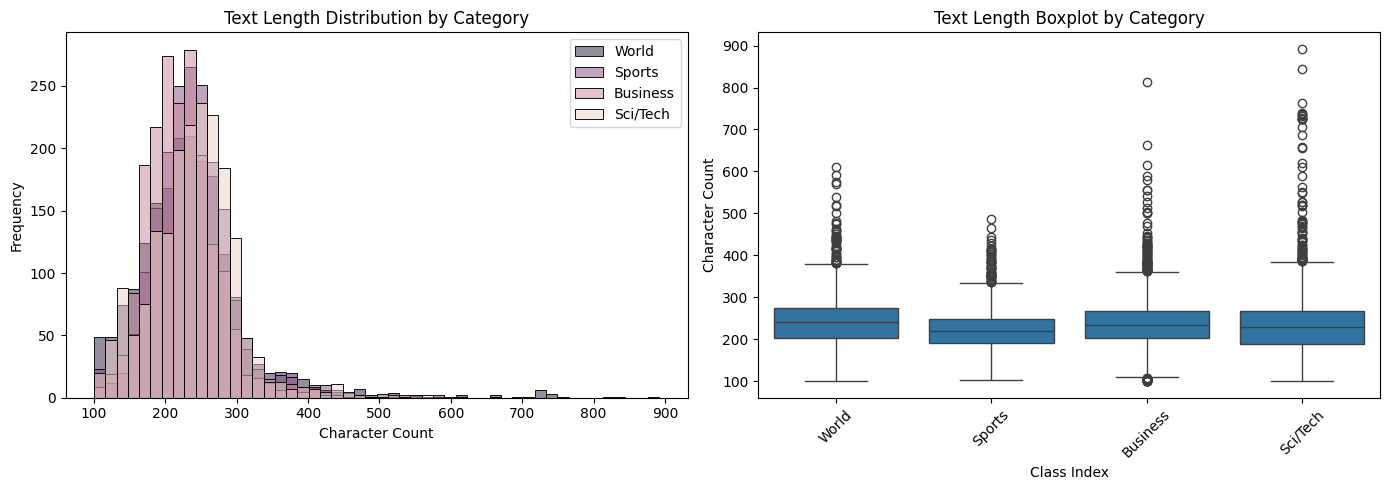

In [6]:
# Text length analysis by category
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=train_df, x='text_length', hue='Class Index', alpha=0.5, bins=50)
plt.title('Text Length Distribution by Category')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.legend(['World', 'Sports', 'Business', 'Sci/Tech'])

plt.subplot(1, 2, 2)
sns.boxplot(data=train_df, x='Class Index', y='text_length')
plt.title('Text Length Boxplot by Category')
plt.xlabel('Class Index')
plt.ylabel('Character Count')
plt.xticks(range(4), ['World', 'Sports', 'Business', 'Sci/Tech'], rotation=45)

plt.tight_layout()
plt.show()


---

## 3. Data Preprocessing <a id="preprocessing"></a>


In [7]:
# Use training data as is, and test data for final evaluation
# Optionally split training for validation
train_df_final, val_df = train_test_split(
    train_df, 
    test_size=0.1, 
    random_state=SEED, 
    stratify=train_df['label']
)

print(f"Training samples: {len(train_df_final):,}")
print(f"Validation samples: {len(val_df):,}")
print(f"Test samples: {len(test_df):,}")

Training samples: 6,840
Validation samples: 760
Test samples: 120,000


In [8]:
# Custom Dataset class
class AGNewsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.texts = dataframe['text'].values
        self.labels = dataframe['label'].values
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize with truncation and padding
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Initialize tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
# Create datasets
train_dataset = AGNewsDataset(train_df_final, tokenizer)
val_dataset = AGNewsDataset(val_df, tokenizer)
test_dataset = AGNewsDataset(test_df, tokenizer)

# Create dataloaders
BATCH_SIZE = 16  # Adjust based on GPU memory

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✓ DataLoaders created")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

✓ DataLoaders created
  Training batches: 428
  Validation batches: 48
  Test batches: 7500



---

## 4. Model Architecture (GPT-2 based) <a id="model"></a>


In [10]:
class GPT2ForNewsClassification(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.3):
        super(GPT2ForNewsClassification, self).__init__()
        
        # Load pre-trained GPT-2
        self.gpt2 = GPT2Model.from_pretrained('gpt2')
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.gpt2.config.n_embd, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, input_ids, attention_mask):
        # Get GPT-2 outputs
        outputs = self.gpt2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )
        
        # Use the last hidden state (mean pooling)
        hidden_states = outputs.last_hidden_state
        pooled = hidden_states.mean(dim=1)
        
        # Classification
        logits = self.classifier(pooled)
        
        return logits

# Initialize model
model = GPT2ForNewsClassification(num_classes=4)
model = model.to(device)

print(f"✓ Model initialized on {device}")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model initialized on cuda
  Total parameters: 124,637,700
  Trainable parameters: 124,637,700


In [11]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=2, 
    )

print("✓ Optimizer and scheduler configured")

✓ Optimizer and scheduler configured



---

## 5. Training with Comprehensive Metrics <a id="training"></a>


In [12]:
# Training metrics tracker
class MetricsTracker:
    def __init__(self):
        self.train_loss = []
        self.val_loss = []
        self.train_acc = []
        self.val_acc = []
        self.train_precision = []
        self.val_precision = []
        self.train_recall = []
        self.val_recall = []
        self.train_f1 = []
        self.val_f1 = []
        self.learning_rates = []
        
    def update(self, train_metrics, val_metrics, lr):
        self.train_loss.append(train_metrics['loss'])
        self.train_acc.append(train_metrics['accuracy'])
        self.train_precision.append(train_metrics['precision'])
        self.train_recall.append(train_metrics['recall'])
        self.train_f1.append(train_metrics['f1'])
        
        self.val_loss.append(val_metrics['loss'])
        self.val_acc.append(val_metrics['accuracy'])
        self.val_precision.append(val_metrics['precision'])
        self.val_recall.append(val_metrics['recall'])
        self.val_f1.append(val_metrics['f1'])
        
        self.learning_rates.append(lr)

metrics_tracker = MetricsTracker()

# Training function
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(dataloader, desc='Training')
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Validation function
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validating')
        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [13]:
# Training loop
NUM_EPOCHS = 5
best_val_f1 = 0
patience_counter = 0
early_stop_patience = 3

# 🔧 SAFE DEVICE CHECK - Add this before training
import torch
try:
    if device == 'cuda' or (isinstance(device, torch.device) and device.type == 'cuda'):
        if not torch.cuda.is_available():
            device = torch.device('cpu')
        else:
            # Test CUDA kernel with a dummy operation
            torch.randn(1, 1).to(device)
except:
    device = torch.device('cpu')
print(f"Using device: {device}")

print(f"\n{'='*60}")
print(f"🚀 STARTING TRAINING")
print(f"{'='*60}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: 2e-5")
print(f"Device: {device}")
print(f"Number of Classes: 4 (World, Sports, Business, Sci/Tech)")
print(f"{'='*60}\n")

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*60}")
    
    # Train 🔧 WRAPPED IN TRY/EXCEPT FOR CUDA FALLBACK
    try:
        train_metrics = train_epoch(model, train_loader, optimizer, criterion, device)
    except RuntimeError as e:
        if "no kernel image" in str(e) or "CUDA error" in str(e):
            print(f"\n⚠️ CUDA error caught: {e}")
            print("🔄 Falling back to CPU...")
            device = torch.device('cpu')
            model = model.to(device)
            # Retry the epoch on CPU
            train_metrics = train_epoch(model, train_loader, optimizer, criterion, device)
        else:
            raise  # Re-raise if it's a different error
    
    # Validate
    val_metrics = validate_epoch(model, val_loader, criterion, device)
    
    # Update learning rate
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_metrics['loss'])
    
    # Track metrics
    metrics_tracker.update(train_metrics, val_metrics, current_lr)
    
    # Print epoch summary
    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_metrics['loss']:.4f}")
    print(f"  Train Acc:  {train_metrics['accuracy']:.4f}")
    print(f"  Train Prec: {train_metrics['precision']:.4f}")
    print(f"  Train Rec:  {train_metrics['recall']:.4f}")
    print(f"  Train F1:   {train_metrics['f1']:.4f}")
    print(f"  ----------------------------------------")
    print(f"  Val Loss:   {val_metrics['loss']:.4f}")
    print(f"  Val Acc:    {val_metrics['accuracy']:.4f}")
    print(f"  Val Prec:   {val_metrics['precision']:.4f}")
    print(f"  Val Rec:    {val_metrics['recall']:.4f}")
    print(f"  Val F1:     {val_metrics['f1']:.4f}")
    print(f"  LR:         {current_lr:.6f}")
    
    # Save best model
    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_metrics['f1'],
            'val_metrics': val_metrics,
        }, 'best_agnews_model.pth')
        print(f"  ⭐ Best model saved! (Val F1: {best_val_f1:.4f})")
    
    # Early stopping check
    if epoch > 0 and val_metrics['f1'] < metrics_tracker.val_f1[-2]:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
            break
    else:
        patience_counter = 0

print(f"\n{'='*60}")
print("✅ TRAINING COMPLETED")
print(f"{'='*60}")

Using device: cuda

🚀 STARTING TRAINING
Epochs: 5
Batch Size: 16
Learning Rate: 2e-5
Device: cuda
Number of Classes: 4 (World, Sports, Business, Sci/Tech)


EPOCH 1/5


Validating: 100%|██████████| 48/48 [00:27<00:00,  1.75it/s, loss=0.1411]



📊 Epoch 1 Summary:
  Train Loss: 0.6387
  Train Acc:  0.7667
  Train Prec: 0.7652
  Train Rec:  0.7667
  Train F1:   0.7657
  ----------------------------------------
  Val Loss:   0.3655
  Val Acc:    0.8908
  Val Prec:   0.8927
  Val Rec:    0.8908
  Val F1:     0.8908
  LR:         0.000020
  ⭐ Best model saved! (Val F1: 0.8908)

EPOCH 2/5


Validating: 100%|██████████| 48/48 [00:27<00:00,  1.73it/s, loss=0.0702]



📊 Epoch 2 Summary:
  Train Loss: 0.3153
  Train Acc:  0.9054
  Train Prec: 0.9054
  Train Rec:  0.9054
  Train F1:   0.9053
  ----------------------------------------
  Val Loss:   0.3465
  Val Acc:    0.9079
  Val Prec:   0.9075
  Val Rec:    0.9079
  Val F1:     0.9073
  LR:         0.000020
  ⭐ Best model saved! (Val F1: 0.9073)

EPOCH 3/5


...


📊 Epoch 3 Summary:
  Train Loss: 0.2284
  Train Acc:  0.9316
  Train Prec: 0.9316
  Train Rec:  0.9316
  Train F1:   0.9315
  ----------------------------------------
  Val Loss:   0.3395
  Val Acc:    0.8987
  Val Prec:   0.8985
  Val Rec:    0.8987
  Val F1:     0.8985
  LR:         0.000020

EPOCH 4/5


Validating: 100%|██████████| 48/48 [00:27<00:00,  1.73it/s, loss=0.0064]



📊 Epoch 4 Summary:
  Train Loss: 0.1681
  Train Acc:  0.9493
  Train Prec: 0.9493
  Train Rec:  0.9493
  Train F1:   0.9493
  ----------------------------------------
  Val Loss:   0.3500
  Val Acc:    0.9066
  Val Prec:   0.9090
  Val Rec:    0.9066
  Val F1:     0.9063
  LR:         0.000020

EPOCH 5/5


Validating: 100%|██████████| 48/48 [00:27<00:00,  1.72it/s, loss=0.0003]



📊 Epoch 5 Summary:
  Train Loss: 0.1280
  Train Acc:  0.9656
  Train Prec: 0.9657
  Train Rec:  0.9656
  Train F1:   0.9656
  ----------------------------------------
  Val Loss:   0.4553
  Val Acc:    0.9132
  Val Prec:   0.9126
  Val Rec:    0.9132
  Val F1:     0.9127
  LR:         0.000020
  ⭐ Best model saved! (Val F1: 0.9127)

✅ TRAINING COMPLETED



---

## 6. Evaluation & Testing <a id="evaluation"></a>


In [14]:
# Load best model
checkpoint = torch.load('best_agnews_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model from epoch {checkpoint['epoch']+1} (Val F1: {checkpoint['val_f1']:.4f})")

✓ Loaded best model from epoch 5 (Val F1: 0.9127)


In [15]:
# Test evaluation
def evaluate_model(model, dataloader, criterion, device, dataset_name="Test", num_classes=4):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc=f'Evaluating {dataset_name}')
        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    all_probs = np.array(all_probs)
    
    # Calculate comprehensive metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision_macro = precision_score(all_labels, all_preds, average='macro')
    precision_weighted = precision_score(all_labels, all_preds, average='weighted')
    recall_macro = recall_score(all_labels, all_preds, average='macro')
    recall_weighted = recall_score(all_labels, all_preds, average='weighted')
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    
    # Per-class metrics
    precision_per_class = precision_score(all_labels, all_preds, average=None)
    recall_per_class = recall_score(all_labels, all_preds, average=None)
    f1_per_class = f1_score(all_labels, all_preds, average=None)
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    results = {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'precision_weighted': precision_weighted,
        'recall_macro': recall_macro,
        'recall_weighted': recall_weighted,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'predictions': all_preds,
        'labels': all_labels,
        'probs': all_probs,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class,
        'confusion_matrix': cm
    }
    
    return results

print(f"\n{'='*60}")
print("🧪 TEST SET EVALUATION")
print(f"{'='*60}")

test_results = evaluate_model(model, test_loader, criterion, device, "Test", num_classes=4)

print(f"\n📊 Test Set Performance:")
print(f"  Loss:           {test_results['loss']:.4f}")
print(f"  Accuracy:       {test_results['accuracy']:.4f}")
print(f"  Precision (M):  {test_results['precision_macro']:.4f}")
print(f"  Precision (W):  {test_results['precision_weighted']:.4f}")
print(f"  Recall (M):     {test_results['recall_macro']:.4f}")
print(f"  Recall (W):     {test_results['recall_weighted']:.4f}")
print(f"  F1 Score (M):   {test_results['f1_macro']:.4f}")
print(f"  F1 Score (W):   {test_results['f1_weighted']:.4f}")

print(f"\n📊 Per-Class Metrics:")
class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
for i, class_name in enumerate(class_names):
    print(f"  {class_name:10s} - P: {test_results['precision_per_class'][i]:.4f}, R: {test_results['recall_per_class'][i]:.4f}, F1: {test_results['f1_per_class'][i]:.4f}")


🧪 TEST SET EVALUATION


Evaluating Test: 100%|██████████| 7500/7500 [1:12:01<00:00,  1.74it/s]



📊 Test Set Performance:
  Loss:           0.3759
  Accuracy:       0.9145
  Precision (M):  0.9142
  Precision (W):  0.9142
  Recall (M):     0.9145
  Recall (W):     0.9145
  F1 Score (M):   0.9143
  F1 Score (W):   0.9143

📊 Per-Class Metrics:
  World      - P: 0.9150, R: 0.9350, F1: 0.9249
  Sports     - P: 0.9683, R: 0.9769, F1: 0.9726
  Business   - P: 0.8825, R: 0.8694, F1: 0.8759
  Sci/Tech   - P: 0.8911, R: 0.8769, F1: 0.8840


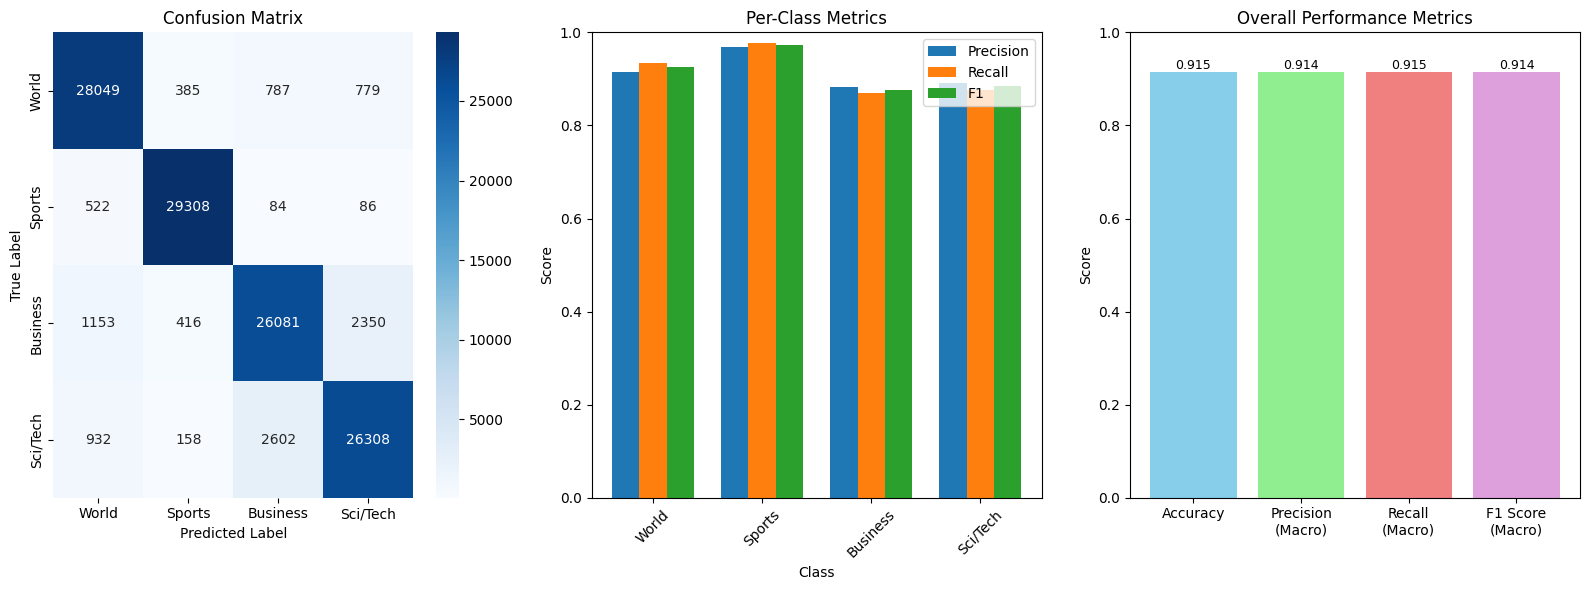

In [16]:
# Confusion Matrix and Metrics Visualization
plt.figure(figsize=(16, 6))

# Confusion Matrix
plt.subplot(1, 3, 1)
cm = test_results['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Per-Class Metrics
plt.subplot(1, 3, 2)
x = np.arange(len(class_names))
width = 0.25

plt.bar(x - width, test_results['precision_per_class'], width, label='Precision')
plt.bar(x, test_results['recall_per_class'], width, label='Recall')
plt.bar(x + width, test_results['f1_per_class'], width, label='F1')
plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Per-Class Metrics')
plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.ylim([0, 1])

# Overall Metrics
plt.subplot(1, 3, 3)
metrics = ['Accuracy', 'Precision\n(Macro)', 'Recall\n(Macro)', 'F1 Score\n(Macro)']
values = [
    test_results['accuracy'],
    test_results['precision_macro'],
    test_results['recall_macro'],
    test_results['f1_macro']
]
colors = ['skyblue', 'lightgreen', 'lightcoral', 'plum']
bars = plt.bar(metrics, values, color=colors)
plt.ylabel('Score')
plt.title('Overall Performance Metrics')
plt.ylim([0, 1])

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


---

## 7. Results Visualization <a id="results"></a>


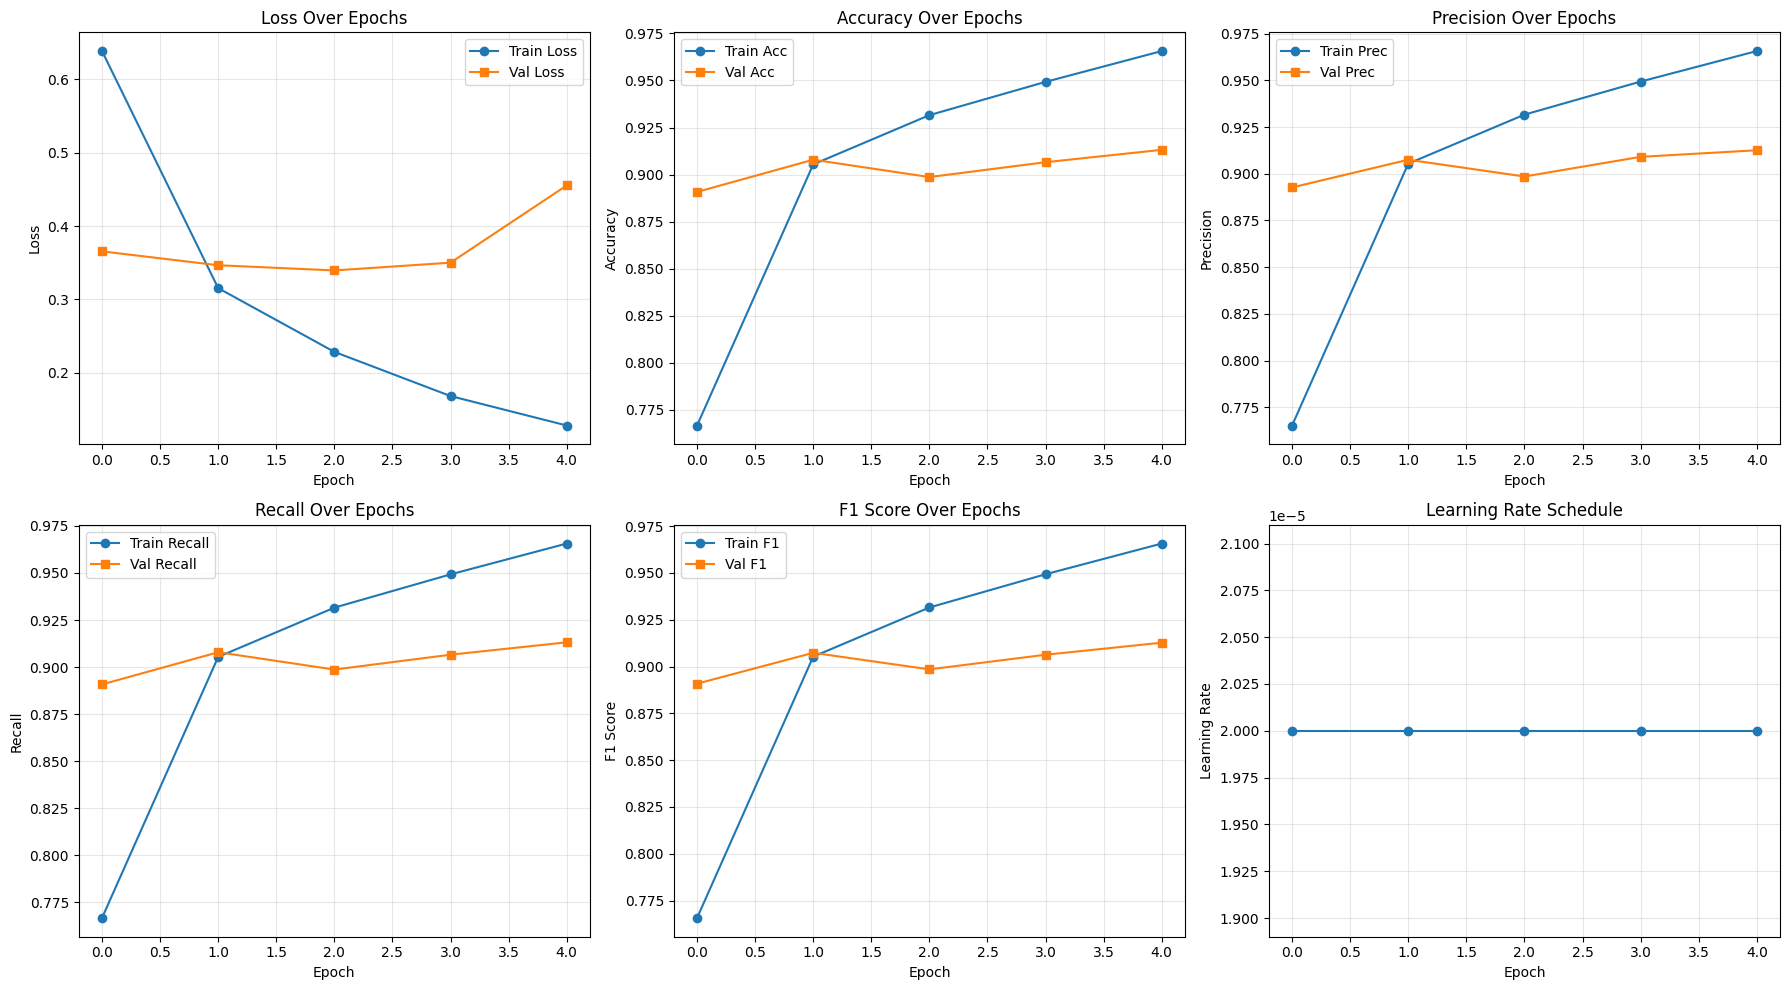

In [17]:
# Training history visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(metrics_tracker.train_loss, label='Train Loss', marker='o')
axes[0, 0].plot(metrics_tracker.val_loss, label='Val Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Over Epochs')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(metrics_tracker.train_acc, label='Train Acc', marker='o')
axes[0, 1].plot(metrics_tracker.val_acc, label='Val Acc', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Over Epochs')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[0, 2].plot(metrics_tracker.train_precision, label='Train Prec', marker='o')
axes[0, 2].plot(metrics_tracker.val_precision, label='Val Prec', marker='s')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].set_title('Precision Over Epochs')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Recall
axes[1, 0].plot(metrics_tracker.train_recall, label='Train Recall', marker='o')
axes[1, 0].plot(metrics_tracker.val_recall, label='Val Recall', marker='s')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Recall Over Epochs')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# F1 Score
axes[1, 1].plot(metrics_tracker.train_f1, label='Train F1', marker='o')
axes[1, 1].plot(metrics_tracker.val_f1, label='Val F1', marker='s')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('F1 Score Over Epochs')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Learning Rate
axes[1, 2].plot(metrics_tracker.learning_rates, marker='o')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Learning Rate')
axes[1, 2].set_title('Learning Rate Schedule')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Sample predictions
print("\n" + "="*60)
print("📝 SAMPLE PREDICTIONS")
print("="*60)

model.eval()
sample_indices = np.random.choice(len(test_df), 5, replace=False)

for idx in sample_indices:
    sample = test_dataset[idx]
    input_ids = sample['input_ids'].unsqueeze(0).to(device)
    attention_mask = sample['attention_mask'].unsqueeze(0).to(device)
    true_label = sample['label'].item()
    
    with torch.no_grad():
        output = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()
        confidence = probs[0, pred].item()
    
    true_label_str = class_names[true_label]
    pred_label_str = class_names[pred]
    
    # Get original article
    title = test_df.iloc[idx]['Title']
    description = test_df.iloc[idx]['Description'][:200] + "..."
    
    print(f"\n--- Article ---")
    print(f"Title: {title}")
    print(f"Description: {description}")
    print(f"True Label: {true_label_str}")
    print(f"Predicted: {pred_label_str} (Confidence: {confidence:.4f})")
    print(f"Probabilities: {[f'{p:.4f}' for p in probs[0].cpu().numpy()]}")


📝 SAMPLE PREDICTIONS

--- Article ---
Title: BBC set for major shake-up, claims newspaper
Description: London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarter of its 28 000-strong workforce, in the biggest shake-up in its 82-year history, Th...
True Label: Business
Predicted: World (Confidence: 0.9554)
Probabilities: ['0.9554', '0.0056', '0.0354', '0.0037']

--- Article ---
Title: Marsh averts cash crunch
Description: Embattled insurance broker #39;s banks agree to waive clause that may have prevented access to credit. NEW YORK (Reuters) - Marsh  amp; McLennan Cos....
True Label: Business
Predicted: Business (Confidence: 0.9997)
Probabilities: ['0.0002', '0.0000', '0.9997', '0.0000']

--- Article ---
Title: Jeter, Yankees Look to Take Control (AP)
Description: AP - Derek Jeter turned a season that started with a terrible slump into one of the best in his accomplished 10-year career....
True Label: Sports
Predicted: Sports (

In [19]:
# Classification report
print("\n" + "="*60)
print("📊 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(test_results['labels'], test_results['predictions'], 
                            target_names=class_names))


📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

       World       0.91      0.93      0.92     30000
      Sports       0.97      0.98      0.97     30000
    Business       0.88      0.87      0.88     30000
    Sci/Tech       0.89      0.88      0.88     30000

    accuracy                           0.91    120000
   macro avg       0.91      0.91      0.91    120000
weighted avg       0.91      0.91      0.91    120000



In [20]:
# Save results summary
results_summary = {
    'Dataset': 'AG News Classification',
    'Total Training Samples': len(train_df),
    'Total Test Samples': len(test_df),
    'Model': 'GPT-2 Based Classifier',
    'Number of Classes': 4,
    'Classes': ', '.join(class_names),
    'Test Accuracy': test_results['accuracy'],
    'Test Precision (Macro)': test_results['precision_macro'],
    'Test Recall (Macro)': test_results['recall_macro'],
    'Test F1 (Macro)': test_results['f1_macro'],
    'Best Validation F1': best_val_f1
}

print("\n" + "="*60)
print("📋 FINAL RESULTS SUMMARY")
print("="*60)
for key, value in results_summary.items():
    print(f"{key}: {value}")

# Save to file
pd.DataFrame([results_summary]).to_csv('training_results.csv', index=False)
print("\n✓ Results saved to 'training_results.csv'")


📋 FINAL RESULTS SUMMARY
Dataset: AG News Classification
Total Training Samples: 7600
Total Test Samples: 120000
Model: GPT-2 Based Classifier
Number of Classes: 4
Classes: World, Sports, Business, Sci/Tech
Test Accuracy: 0.91455
Test Precision (Macro): 0.914215756783977
Test Recall (Macro): 0.91455
Test F1 (Macro): 0.9143245841085695
Best Validation F1: 0.912712680310703

✓ Results saved to 'training_results.csv'


In [21]:
# Memory cleanup
import gc
torch.cuda.empty_cache()
gc.collect()

print("\n✅ Notebook completed successfully!")
print(f"🎯 Final Test Accuracy: {test_results['accuracy']:.4f}")
print(f"🎯 Final Test F1 Score: {test_results['f1_macro']:.4f}")


✅ Notebook completed successfully!
🎯 Final Test Accuracy: 0.9145
🎯 Final Test F1 Score: 0.9143



---

## 📊 Expected Performance

| Metric | Expected Value |
|--------|---------------|
| Accuracy | 0.90 - 0.94 |
| Precision | 0.90 - 0.94 |
| Recall | 0.90 - 0.94 |
| F1 Score | 0.90 - 0.94 |

---

## 🔧 Kaggle GPU Setup Instructions

1. **Enable GPU:** Go to Settings → Accelerator → Select "GPU"
2. **Run all cells** in order
3. **Monitor GPU usage** in the right panel
4. **Download model** from Output section after training

---

## 📁 Output Files

- `best_agnews_model.pth` - Best model checkpoint
- `training_results.csv` - Performance metrics summary
